[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Übung / Exercise 8 Discrete-Time Convolution

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

## Task:

Calculate and plot the convolution result
\begin{equation}
y[k] = x[k] * h[k]
\end{equation}
of the two finite length, discrete-time signals
\begin{align}
&x[k] = [1,2,3,4] \quad &\mathrm{for} \quad &k = [2,3,4,5]\\
&h[k] = [8,0,7,6,5] \quad &\mathrm{for} \quad &k = [-2,-1,0,1,2]
\end{align}
depicted in the plots below. These signals shall be zero outside the visible range.

([<matplotlib.axis.YTick at 0x1152cc340>,
 [Text(0, 0, '0'),
  Text(0, 1, ''),
  Text(0, 2, ''),
  Text(0, 3, ''),
  Text(0, 4, ''),
  Text(0, 5, '5'),
  Text(0, 6, '6'),
  Text(0, 7, '7'),
  Text(0, 8, '8')])

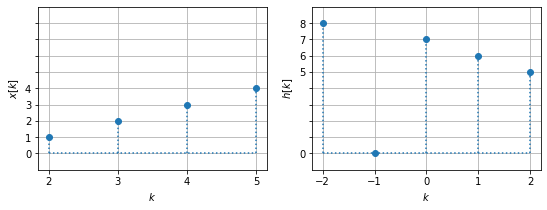

In [2]:
plt.figure(figsize=(9, 3))

kx = (2, 3, 4, 5)
x = (1, 2, 3, 4)
ax = plt.subplot(1, 2, 1)
plt.stem(kx, x, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(True)
plt.xlabel(r'$k$')
plt.ylabel(r'$x[k]$')
plt.ylim((-1, 9))
plt.yticks(np.arange(0, 9), ['0', '1', '2', '3', '4', '', '', '', ''])

kh = (-2, -1, 0, 1, 2)
h = (8, 0, 7, 6, 5)
ax = plt.subplot(1, 2, 2)
plt.stem(kh, h, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(True)
plt.xlabel(r'$k$')
plt.ylabel(r'$h[k]$')
plt.ylim((-1, 9))
plt.yticks(np.arange(0, 9), ['0', '', '', '', '', '5', '6', '7', '8'])

## Solution

We elaborate three different ways of calculating the result and validate these with the result computed by the `numpy` implementation.

A highly recommended reference not only for this topic, but generally on digital signal processing basics, is

[Lyo11] Richard G. Lyons (2011): "*Understanding Digital Signal Processing*", Prentice Hall, Upper Saddle River, NJ (USA), 3rd ed.


### Numpy Result

To get an expectation on the result, we check the solution using a computer.
For that, numpy's `convolve` function can be used.
Normally, you would need to verify a used algorithm beforehand.
In this case it is fair to assume, that `convolve` is properly implemented and yields the correct convolution result.
This is depicted below.

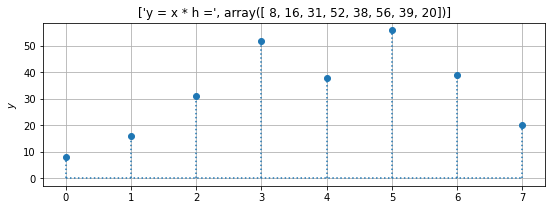

In [3]:
y = np.convolve(x, h)

plt.figure(figsize=(9, 3))
ax = plt.subplot(1, 1, 1)
plt.stem(y, use_line_collection=True, linefmt='C0:',
         markerfmt='C0o', basefmt='C0:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.ylabel(r'$y$')
plt.title(['y = x * h =', y])
plt.grid(True)

`convolve` returns a sequence of numbers as the convolution result, but we do not know yet, how $y$ is aligned with respect to $k$.
The `convolve` function does not care and actually does not need to know about the time alignment.
The other way around: both sequences are treated as they would both start at $k=0$.
The physical link of the sequence towards a discrete-time index is something we made up.
Thus, it is our task to figure this out.
For the moment we must leave the x-axis in the plot unlabeled.  

### Convolution

The discrete-time convolution is defined as
\begin{equation}
y[k] = \sum\limits_{\kappa = -\infty}^{+\infty} x[k -\kappa] \cdot h[\kappa] = \sum\limits_{\kappa = -\infty}^{+\infty} x[\kappa] \cdot h[k -\kappa]
\end{equation}
with $k, \kappa\in\mathbb{Z}$.
We might either take $x$ as the signal to be shifted and mirrored ($x[k -\kappa]$) or take $h$ as the signal to be shifted and mirrored ($h[k -\kappa]$).
The result is identical and the choice is a matter of taste when performing manual calculations.
For the given example, mirroring and shifting the signal $x$ seems to be a bit more conclusive.
In pratice, the first version is meaningful, when we consider the impulse response $h[k]$ given and fix, and input signal is 'coming in' to the system, which then needs to delayed by all possible $\kappa$.

Since we deal with finite length sequences (in fact: if we interpret $h[k]$ as the impulse response of an LTI system, this then constitutes a finite impulse response (FIR) filter), the summation is not required to be performed from $-\infty \leq \kappa \leq \infty$, but rather for a limited range that depends on the actual $k$.

This is elaborated in the following solution, where version I of III potential approaches is presented.

### Solution I: Analytical Method based on the Convolution Equation

This version might be the most straightforward, but potentially least enlightening. 
See Ch. 5.9.1 in [Lyo11] for another example using the same approach.
We use the convolution equation
\begin{equation}
y[k] = \sum\limits_{\kappa = -\infty}^{+\infty} x[k -\kappa] \cdot h[\kappa]
\end{equation}
directly to solve for the two sequences in the picture below.
Note that as reference we now depict $x[\nu]$ and $h[\nu]$ with $\nu\in\mathbb{Z}$ to be able to grab values out $x$ for $\nu=k-\kappa$ and out of $h$ for $\nu=\kappa$.

([<matplotlib.axis.YTick at 0x115561f70>,
 [Text(0, 0, '0'),
  Text(0, 1, ''),
  Text(0, 2, ''),
  Text(0, 3, ''),
  Text(0, 4, ''),
  Text(0, 5, '5'),
  Text(0, 6, '6'),
  Text(0, 7, '7'),
  Text(0, 8, '8')])

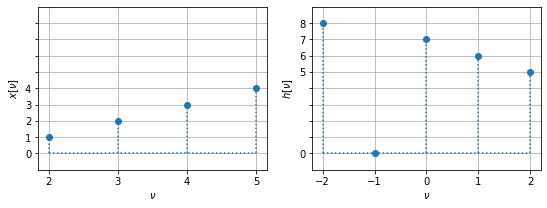

In [4]:
plt.figure(figsize=(9, 3))

ax = plt.subplot(1, 2, 1)
plt.stem(kx, x, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(True)
plt.xlabel(r'$\nu$')
plt.ylabel(r'$x[\nu]$')
plt.ylim((-1, 9))
plt.yticks(np.arange(0, 9), ['0', '1', '2', '3', '4', '', '', '', ''])

ax = plt.subplot(1, 2, 2)
plt.stem(kh, h, use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.grid(True)
plt.xlabel(r'$\nu$')
plt.ylabel(r'$h[\nu]$')
plt.ylim((-1, 9))
plt.yticks(np.arange(0, 9), ['0', '', '', '', '', '5', '6', '7', '8'])

The required summation range for $\kappa$ depends on the actual $k$.
Thus in the first instance, for a specific $k$ it is helpful to indicate the minimum $\kappa$ and the maximum $\kappa$, such that all non-zero entries of $x[\nu=k-\kappa]$ and $h[\nu=\kappa]$ are covered.

For $k=0$ this yields
\begin{align}
y[0] = \sum\limits_{\kappa = -5}^{+2} x[0 -\kappa] \cdot h[\kappa] =
&x[0 -(-5)] \cdot h[-5]\\
+&x[0 -(-4)] \cdot h[-4]\\
+&x[0 -(-3)] \cdot h[-3]\\
+&x[0 -(-2)] \cdot h[-2]\\
+&x[0 -(-1)] \cdot h[-1]\\
+&x[0 -(0)] \cdot h[0]\\
+&x[0 -(1)] \cdot h[1]\\
+&x[0 -(2)] \cdot h[2]
\end{align}
since $\kappa=-5$ and $k=0$ refers to $x[\nu=k-\kappa = 5]$ and $\kappa=+2$ refers to $h[\nu=\kappa=2]$ as the most 'right' non-zero entries.
Both choices also cover the most 'left' non-zero entries $x[2]$ and $h[-2]$.

In the second step, we see that actually only for $\kappa=-2$, both $x$ and $h$ exhibit non-zero contributions, thus the summation reduces to 
\begin{align}
y[0] = \sum\limits_{\kappa = -2}^{-2} x[0 -\kappa] \cdot h[\kappa] = x[0 -(-2)] \cdot h[-2] = 1 \cdot 8 = 8.
\end{align}

For $k=1$ we take the same considerations.
In step one, the sum
\begin{align}
y[1] = \sum\limits_{\kappa = -4}^{+2} x[1 -\kappa] \cdot h[\kappa] =
&x[1 -(-4)] \cdot h[-4]\\
+&x[1 -(-3)] \cdot h[-3]\\
+&x[1 -(-2)] \cdot h[-2]\\
+&x[1 -(-1)] \cdot h[-1]\\
+&x[1 -(0)] \cdot h[0]\\
+&x[1 -(1)] \cdot h[1]\\
+&x[1 -(2)] \cdot h[2]
\end{align}
covers all potential non-zero entries in $x[\mu]$ and $h[\mu]$ at according positions $\mu$. Then, we can realize that actually only
\begin{align}
y[1] = \sum\limits_{\kappa = -2}^{-1} x[1 -\kappa] \cdot h[\kappa] =
&x[1 -(-2)] \cdot h[-2]\\
+&x[1 -(-1)] \cdot h[-1] = 2\cdot 8 + 1\cdot 0 = 16 
\end{align}
contribute in the summation.
Note that actually $h[\nu=\kappa=-1]=0$ does not contribute, but we should treat it for clarity, because this zero is surrounded by other non-zero samples in the FIR $h$.

For $k=2$ we get
\begin{align}
y[2] = \sum\limits_{\kappa = -3}^{+2} x[2 -\kappa] \cdot h[\kappa] =
&x[2 -(-3)] \cdot h[-3]\\
+&x[2 -(-2)] \cdot h[-2]\\
+&x[2 -(-1)] \cdot h[-1]\\
+&x[2 -(0)] \cdot h[0]\\
+&x[2 -(1)] \cdot h[1]\\
+&x[2 -(2)] \cdot h[2],
\end{align}
where summation can be reduced to the non-zero contributions
\begin{align}
y[2] = \sum\limits_{\kappa = -2}^{0} x[2 -\kappa] \cdot h[\kappa] =
&x[2 -(-2)] \cdot h[-2]\\
+&x[2 -(-1)] \cdot h[-1]\\
+&x[2 -(0)] \cdot h[0] = 3\cdot 8 + 2\cdot 0 + 1\cdot 7 = 31.
\end{align}

For $k=3$ we get
\begin{align}
y[3] = \sum\limits_{\kappa = -2}^{+2} x[3 -\kappa] \cdot h[\kappa] =
&x[3 -(-2)] \cdot h[-2]\\
+&x[3 -(-1)] \cdot h[-1]\\
+&x[3 -(0)] \cdot h[0]\\
+&x[3 -(1)] \cdot h[1]\\
+&x[3 -(2)] \cdot h[2],
\end{align}
where summation can be reduced to the non-zero contributions
\begin{align}
y[3] = \sum\limits_{\kappa = -2}^{+1} x[3 -\kappa] \cdot h[\kappa] =
&x[3 -(-2)] \cdot h[-2]\\
+&x[3 -(-1)] \cdot h[-1]\\
+&x[3 -(0)] \cdot h[0]\\
+&x[3 -(1)] \cdot h[1] = 4\cdot 8 + 3\cdot 0 + 2\cdot 7 + 1\cdot 6 = 52.
\end{align}

For $k=4$ we get
\begin{align}
y[4] = \sum\limits_{\kappa = -2}^{+2} x[4 -\kappa] \cdot h[\kappa] =
&x[4 -(-2)] \cdot h[-2]\\
+&x[4 -(-1)] \cdot h[-1]\\
+&x[4 -(0)] \cdot h[0]\\
+&x[4 -(1)] \cdot h[1]\\
+&x[4 -(2)] \cdot h[2],
\end{align}
where summation can be reduced to the non-zero contributions
\begin{align}
y[4] = \sum\limits_{\kappa = -1}^{+2} x[4 -\kappa] \cdot h[\kappa] =
&x[4 -(-1)] \cdot h[-1]\\
+&x[4 -(0)] \cdot h[0]\\
+&x[4 -(1)] \cdot h[1]\\
+&x[4 -(2)] \cdot h[2] = 4\cdot 0 + 3\cdot 7 + 2\cdot 6 + 1\cdot 5 = 38.
\end{align}

For $k=5$ we get
\begin{align}
y[5] = \sum\limits_{\kappa = -2}^{+3} x[5 -\kappa] \cdot h[\kappa] =
&x[5 -(-2)] \cdot h[-2]\\
+&x[5 -(-1)] \cdot h[-1]\\
+&x[5 -(0)] \cdot h[0]\\
+&x[5 -(1)] \cdot h[1]\\
+&x[5 -(2)] \cdot h[2]\\
+&x[5 -(3)] \cdot h[3],
\end{align}
where summation can be reduced to the non-zero contributions
\begin{align}
y[5] = \sum\limits_{\kappa = 0}^{+2} x[5 -\kappa] \cdot h[\kappa] =
&x[5 -(0)] \cdot h[0]\\
+&x[5 -(1)] \cdot h[1]\\
+&x[5 -(2)] \cdot h[2] = 4\cdot 7 + 3\cdot 6 + 2\cdot 5 = 56.
\end{align}

For $k=6$ we get
\begin{align}
y[6] = \sum\limits_{\kappa = -2}^{+4} x[6 -\kappa] \cdot h[\kappa] =
&x[6 -(-2)] \cdot h[-2]\\
+&x[6 -(-1)] \cdot h[-1]\\
+&x[6 -(0)] \cdot h[0]\\
+&x[6 -(1)] \cdot h[1]\\
+&x[6 -(2)] \cdot h[2]\\
+&x[6 -(3)] \cdot h[3]\\
+&x[6 -(4)] \cdot h[4],
\end{align}
where summation can be reduced to the non-zero contributions
\begin{align}
y[6] = \sum\limits_{\kappa = +1}^{+2} x[6 -\kappa] \cdot h[\kappa] =
&x[6 -(1)] \cdot h[1]\\
+&x[6 -(2)] \cdot h[2] = 4\cdot 6 + 3\cdot 5 = 39.
\end{align}

For $k=7$ we get
\begin{align}
y[7] = \sum\limits_{\kappa = -2}^{+5} x[7 -\kappa] \cdot h[\kappa] =
&x[7 -(-2)] \cdot h[-2]\\
+&x[7 -(-1)] \cdot h[-1]\\
+&x[7 -(0)] \cdot h[0]\\
+&x[7 -(1)] \cdot h[1]\\
+&x[7 -(2)] \cdot h[2]\\
+&x[7 -(3)] \cdot h[3]\\
+&x[7 -(4)] \cdot h[4]\\
+&x[7 -(5)] \cdot h[5],
\end{align}
where summation can be reduced to the non-zero contribution
\begin{align}
y[7] = \sum\limits_{\kappa = +2}^{+2} x[7 -\kappa] \cdot h[\kappa] =
+&x[7 -(2)] \cdot h[2] = 4\cdot 5 = 20.
\end{align}

You might verify that for all other $k$ the convolution result $y[k]=0$.
Thus, we now know the correct time alignment $0\leq k \leq 7$ of the sequence that was computed by `numpy`, which we just verified by our manual calculus.
The plot of the convolution result with proper labeling is depicted below.
Note that starting the manual calculus at $k=0$ that just resulted in the first non-zero entry of $y$ is a coincidence.
For other $x$ and $h$ the time alignment must be properly checked with the handling discussed above.

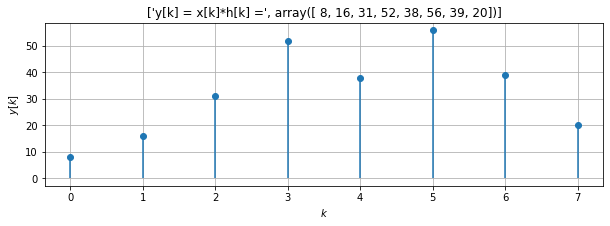

In [5]:
y = np.convolve(x, h)
N = len(x)+len(h)-1  # length of y
M = len(y)  # N == M!
k = np.arange(0, M)  # time alignment valid for the specific example
plt.figure(figsize=(10, 3))
ax = plt.subplot(1, 1, 1)
plt.stem(k, y, basefmt='None')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.ylabel(r'$y[k]$')
plt.xlabel(r'$k$')
plt.title(['y[k] = x[k]*h[k] =', y])
plt.grid(True)

### Solution II: ASCII-Graphics' Method to Visualise Mirroring and Shifting

Virtually every textbook on discrete-time signal processing treats the convolution of sequences in an illustrative manner.

See for example
Bernd Girod, Rudolf Rabenstein, Alexander Stenger (2001): "*Signals and Systems*." Wiley, Chichester (UK), Ch. 14.6.4

It is also treated in Ch. 5.9.1 of [Lyo11].

We already have dealt with the graphical representation for continuous-time signals, please see [convolution.ipynb](https://github.com/spatialaudio/signals-and-systems-lecture/blob/master/systems_time_domain/convolution.ipynb)
to recapitulate.

We use this concept now for the convolution of the two discrete-time signals $x$ and $h$ given above.
Instead of providing and explaining the approach with stem plots as usually, we treat this as a little Python programming task, where nicely formated `print` output clarifies the concept of mirroring, shifting and multiplying/accumulating.
Very similar this output could be manually performed in a written exam.

First, let us set up the signals $x$ and $h$ with the correct time alignment with respect to $\kappa$.
For that, inserting additional zeros is meaningful to bring both vectors to length $N = N_x + N_h -1 = 8$.
Note that instead of $\kappa$ we use the letter v in the little program and the print out for improved readability.
The print out shows $\kappa$ (which is treated as v), $x[\kappa]$ and $h[\kappa]$ properly aligned.

In [6]:
x = np.array([0, 0, 0, 0, 1, 2, 3, 4])  # length Nx = 4 of x
h = np.array([8, 0, 7, 6, 5, 0, 0, 0])  # length Nh = 5 of h
v = np.arange(-2, 6)  # length N = Nx + Nh - 1 = 8 of resulting non-zero y
# print with integer sign
np.set_printoptions(formatter={'int': '{:+}'.format})
print('  v  = ' + str(v))
print('x[v] = ' + str(x))
print('h[v] = ' + str(h))

  v  = [-2 -1 +0 +1 +2 +3 +4 +5]
x[v] = [+0 +0 +0 +0 +1 +2 +3 +4]
h[v] = [+8 +0 +7 +6 +5 +0 +0 +0]


Second, we deploy a for loop to get the convolution result $y[k]$ for all required $0\leq k \leq 7$.

Within this loop, we mirror the array x (actually we reverse the order of the array's entries) and afterwards apply a circular shift by $k$.

The second and third print operation do the proper alignment between $x[k-\kappa]$ and $h[\kappa]$ for the print out.

All pairs of $x[k-\kappa]$ and $h[\kappa]$ that overlap in the print out need to be [multiplied and accumulated (MAC)](https://en.wikipedia.org/wiki/Multiply–accumulate_operation) to yield $y[k]$.
This is realized in the last print operation, which also prints the convolution result.

To keep it easily understandable, the little program contains some hard coded numbers specific to the chosen example.
You might think of a more general solution by introducing variables that handle the different array alignments for other examples.
After this has been done, one might get rid of the print outs and ends with a compact (but for large $N$ not very performant) code for calculation of the convolution in Python.

In [7]:
np.set_printoptions()  # reset print out of integers
for k in range(0, 8):  # hard coded
    tmp = np.roll(np.flip(x), k)  # important: roll is a circular shift here
    print('circ shift x[-v] to right by k = ' + str(k))
    print('x[' + str(k) + '-v] = ' + str(tmp))
    print('h[v]   = ', 4*' ', h)  # hard coded
    print('y[k=' + str(k) + '] = ' +
          str(sum(tmp[3:]*h[0:5])) + '\n')  # hard coded

circ shift x[-v] to right by k = 0
x[0-v] = [4 3 2 1 0 0 0 0]
h[v]   =       [8 0 7 6 5 0 0 0]
y[k=0] = 8

circ shift x[-v] to right by k = 1
x[1-v] = [0 4 3 2 1 0 0 0]
h[v]   =       [8 0 7 6 5 0 0 0]
y[k=1] = 16

circ shift x[-v] to right by k = 2
x[2-v] = [0 0 4 3 2 1 0 0]
h[v]   =       [8 0 7 6 5 0 0 0]
y[k=2] = 31

circ shift x[-v] to right by k = 3
x[3-v] = [0 0 0 4 3 2 1 0]
h[v]   =       [8 0 7 6 5 0 0 0]
y[k=3] = 52

circ shift x[-v] to right by k = 4
x[4-v] = [0 0 0 0 4 3 2 1]
h[v]   =       [8 0 7 6 5 0 0 0]
y[k=4] = 38

circ shift x[-v] to right by k = 5
x[5-v] = [1 0 0 0 0 4 3 2]
h[v]   =       [8 0 7 6 5 0 0 0]
y[k=5] = 56

circ shift x[-v] to right by k = 6
x[6-v] = [2 1 0 0 0 0 4 3]
h[v]   =       [8 0 7 6 5 0 0 0]
y[k=6] = 39

circ shift x[-v] to right by k = 7
x[7-v] = [3 2 1 0 0 0 0 4]
h[v]   =       [8 0 7 6 5 0 0 0]
y[k=7] = 20



**Important Note:**

To make this code somewhat elegant in terms of shifting handling, we deployed a circular shift on $x$.
This means that an entry that is being shifted out at the one array bound is being reinserted at the other array bound.
Thus, instead of filling $x$ left with zeros, entries reappear at the beginning of x.
This can be observed for $k=5,6,7$ where 1,2,3 are successively reinserted.
However, this re-insertion has no impact on the convolution result, since there is no overlap of these values with $h$.
This is due to the initial, properly done zero padding to ensure (i) proper time alignment between $x$ and $h$ and (ii) same lengths $N=N_x+N_h-1$ of $x$, $h$ and $y$.

This handling is also used to perform a [fast linear convolution](https://github.com/spatialaudio/signals-and-systems-lecture/blob/master/discrete_fourier_transform/fast_convolution.ipynb) of two finite length sequences with the help of a cyclic convolution, which corresponds to a multiplication in the [DFT](https://github.com/spatialaudio/signals-and-systems-lecture/blob/master/discrete_fourier_transform/definition.ipynb)-domain.

When doing handwritten calculus, you might ignore this circular shift feature and fill with zeros as plain linear convolution would ask for.

### Solution III: FIR Filtering of Weighted Single Dirac Impulses and Summation of Partial Results

See Fig. 2.8 in Alan V. Oppenheim, Ronald Schafer (2010): "*Discrete-Time Signal Processing*", Pearson, Upper Saddle River, NJ (USA).


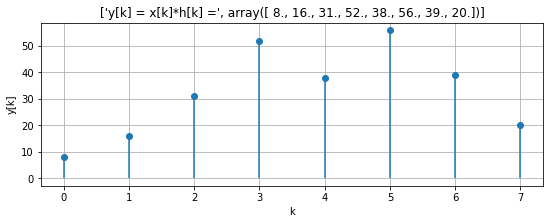

In [8]:
x = np.array([1, 2, 3, 4])
h = np.array([8, 0, 7, 6, 5])
Nx = x.size
Nh = h.size
N = Nx+Nh-1  # length of y
k = np.arange(0, N)  # time alignment valid for the specific example
y = np.zeros(N)
# take one impulse of x and filter it with h (this works since)
y[0:Nh] += x[0]*h
y[1:Nh+1] += x[1]*h  # convolution of a weigthed Dirac with h yields weigthed h
y[2:Nh+2] += x[2]*h  # superposition of all partial results yields precisely
y[3:Nh+3] += x[3]*h  # the convolution result
# note that this implementation works for the specific example, where
# h starts at -2 and x at +2, thus compensating each other and aligning the
# partial signal x[0]*h at k=0
plt.figure(figsize=(9, 3))
ax = plt.subplot(1, 1, 1)
plt.stem(k, y, basefmt='None')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.ylabel('y[k]')
plt.xlabel('k')
plt.title(['y[k] = x[k]*h[k] =', y])
plt.grid(True)

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.